### Modeling

In [55]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("../data/processed/preprocessed_credit_default.csv")

In [56]:
X = df.drop(columns='DEFAULT')
y = df['DEFAULT']

In [57]:
X.head()

,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,20000,24,2,2,-1,-1,-2,-2,3913,3102,...,0,0,0,0,True,True,False,False,False,False
1,120000,26,-1,2,0,0,0,2,2682,1725,...,1000,1000,0,2000,True,True,False,False,True,False
2,90000,34,0,0,0,0,0,0,29239,14027,...,1000,1000,1000,5000,True,True,False,False,True,False
3,50000,37,0,0,0,0,0,0,46990,48233,...,1200,1100,1069,1000,True,True,False,False,False,False
4,50000,57,-1,0,-1,0,0,0,8617,5670,...,10000,9000,689,679,False,True,False,False,False,False


In [58]:
y.head()

0    1
1    1
2    0
3    0
4    0
Name: DEFAULT, dtype: int64


##### 1. Train-Test split


In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [60]:
numeric_cols = [
    'LIMIT_BAL','AGE','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

In [61]:
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

Logistic regression is sensitive to variables measured on different scales. Therefore, continuous variables such as credit limit, age, bill amounts, and payment amounts were standardized, while categorical dummy variables and repayment status variables were left unchanged.

In [62]:
X.to_csv("../data/processed/X_preprocessed.csv", index=False)
y.to_csv("../data/processed/y_preprocessed.csv", index=False)

##### 2. Logistic Regression

In [63]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [64]:
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.809


In [65]:
logreg_pred = model.predict(X_train)
print("Accuracy:", accuracy_score(y_train, logreg_pred))

Accuracy: 0.8122083333333333


In [66]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [67]:
print(confusion_matrix(y_test, pred))

[[4529  144]
 [1002  325]]


In [68]:
from sklearn.model_selection import GridSearchCV

In [69]:
param_grid = {
    'C':[0.01, 0.1, 1, 10],
    'penalty':['l1', 'l2'],
    'solver':['liblinear']
}

In [70]:
grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring='accuracy',
)

In [71]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='accuracy')

In [72]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
0.812375


In [73]:
best_model = grid.best_estimator_

In [74]:
pred = best_model.predict(X_test)

In [75]:
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

Accuracy: 0.8091666666666667
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.70      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000

[[4531  142]
 [1003  324]]


In [76]:
results = pd.DataFrame(grid.cv_results_)

results[['param_C',
         'param_penalty',
         'mean_test_score',
         'rank_test_score']].sort_values('rank_test_score')

,param_C,param_penalty,mean_test_score,rank_test_score
4,1.00,l1,0.812375,1
6,10.00,l1,0.812333,2
7,10.00,l2,0.812333,2
5,1.00,l2,0.812250,4
3,0.10,l2,0.811958,5
2,0.10,l1,0.811958,6
0,0.01,l1,0.810458,7
1,0.01,l2,0.810458,7


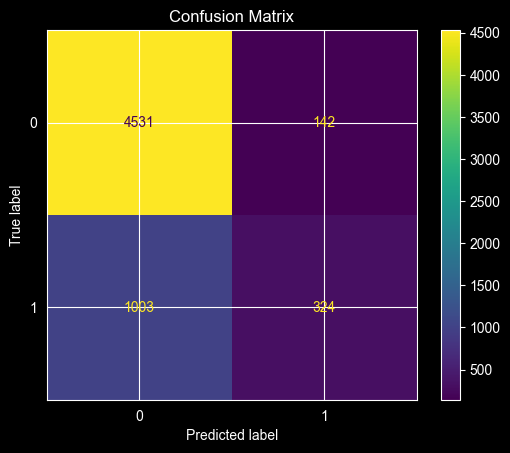

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

plt.title("Confusion Matrix")
plt.show()